# Protein Complexity: Writhe, ACN, and $v_2$
Minimal notebook to load, visualise, and score a protein's alpha carbon backbone using the writhe, average crossing number (ACN), and $v_2$ measures of complexity. The notebook uses the `pyknot` library to compute these measures.

In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'biopython', 'py3Dmol', 'numpy', 'matplotlib', 'requests'])

CompletedProcess(args=['/Users/osperaja/PycharmProjects/pcn-complexity/.venv/bin/python', '-m', 'pip', 'install', '-q', 'biopython', 'py3Dmol', 'numpy', 'matplotlib', 'requests'], returncode=0)

## Load a protein from the PDB

In [2]:
import requests, os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from Bio.PDB import PDBParser

# Choose your character
# 1v9e is a trefoil-knotted protein from Wang & Panagiotou (2022)
# 1j85 is an unknotted protein from the same paper
# 1l8w and 1qop are a good contrast pair for v2 despite having similar Writhe and ACN

PDB_ID = "1qop"

def fetch_pdb(pdb_id: str) -> str:
    """Download a PDB file if not already cached, return local path."""
    path = f'{pdb_id.lower()}.pdb'
    if not os.path.exists(path):
        url = f'https://files.rcsb.org/download/{pdb_id.upper()}.pdb'
        r = requests.get(url)
        r.raise_for_status()
        with open(path, 'w') as f:
            f.write(r.text)
        print(f'Downloaded {pdb_id}.pdb')
    else:
        print(f'Using cached {path}')
    return path

def get_ca_coords(pdb_path: str, chain_id: str = None) -> np.ndarray:
    """
    Extract alpha carbon (C_alpha) coordinates from a PDB file.
    Returns array of shape (N, 3).
    If chain_id is None, uses the first chain.
    """
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure('protein', pdb_path)
    model = structure[0]  # first MODEL record

    # pick chain
    chains = list(model.get_chains())
    chain = next(c for c in chains if c.id == chain_id) if chain_id \
            else chains[0]
    print(f'Using chain {chain.id} with {sum(1 for _ in chain.get_residues())} residues')

    coords = []
    for residue in chain.get_residues():
        if 'CA' in residue:
            coords.append(residue['CA'].get_vector().get_array())
    return np.array(coords)

pdb_path = fetch_pdb(PDB_ID)
ca = get_ca_coords(pdb_path)
print(f'C_alpha atoms extracted: {len(ca)}')

Using cached 1qop.pdb
Using chain A with 554 residues
C_alpha atoms extracted: 265


## Visualise the protein structure

In [3]:
import py3Dmol

with open(pdb_path) as f:
    pdb_str = f.read()

view = py3Dmol.view(width=700, height=500)
view.addModel(pdb_str, 'pdb')

# representation coloured by secondary structure
view.setStyle({'cartoon': {'colorscheme': 'ssJmol'}})
view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Backbone-only visualisation ($C_\alpha$ trace)

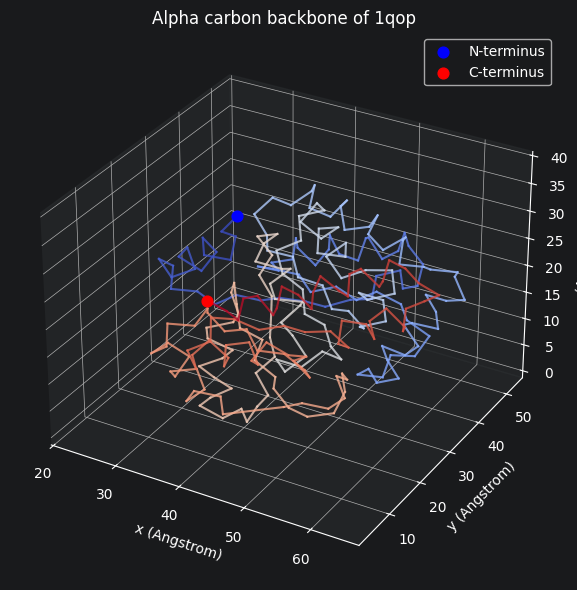

In [4]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# colour by sequence position: blue (N-terminus) -> red (C-terminus)
N = len(ca)
colours = plt.cm.coolwarm(np.linspace(0, 1, N))

for i in range(N-1):
    ax.plot(ca[i:i+2, 0], ca[i:i+2, 1], ca[i:i+2, 2],
            color=colours[i], linewidth=1.5, alpha=0.8)

# mark termini
ax.scatter(*ca[0],  color='blue',  s=60, zorder=5, label='N-terminus')
ax.scatter(*ca[-1], color='red',   s=60, zorder=5, label='C-terminus')

ax.set_title(f'Alpha carbon backbone of {PDB_ID}')
ax.set_xlabel('x (Angstrom)'); ax.set_ylabel('y (Angstrom)'); ax.set_zlabel('z (Angstrom)')
ax.legend()
plt.tight_layout()
plt.show()

## Compute Writhe, and ACN

Let $\gamma : [0,1] \to \mathbb{R}^3$ be a closed curve.

Then,
$$
    \mathrm{Wr}(\gamma) = 1/4\pi \int_{\gamma} \int_{\gamma}
    \frac{(\gamma(t) - \gamma(s)) \cdot (\dot\gamma(t) \times \dot\gamma(s))}
    {\|\gamma(t) - \gamma(s)\|^2}
    \, \mathrm{d}t \, \mathrm{d}s
$$
and
$$
    \mathrm{ACN}(\gamma) = 1/4\pi \int_{\gamma} \int_{\gamma}
    \frac{|(\gamma(t) - \gamma(s)) \cdot (\dot\gamma(t) \times \dot\gamma(s))|}
    {\|\gamma(t) - \gamma(s)\|^3}
    \, \mathrm{d}t \, \mathrm{d}s
$$
where the diagonal $t = s$ is excluded.

$\mathrm{Wr}$ is a signed measure of the average self-crossing number over all projection directions.
Left- and right-handed crossings contribute with opposite signs, so $\mathrm{Wr}$ can be zero for a non-trivial knot.
$\mathrm{ACN}$ replaces the signed contribution of each crossing with its absolute value, so it is a non-negative measure of complexity that is zero only for the unknot.

But a protein is not closed.
We add a closure to $\gamma$ by connecting the N- and C-termini with a straight line 💅

Both measures remain sensitive to local geometry; $\alpha$-helices inflate the measures.

In [5]:
np.float = float # monkey-patch for pyknot unpatched shit
from pyknotid.spacecurves import SpaceCurve, Knot

sc = SpaceCurve(ca, add_closure=True)
wr, acn = sc.writhe(include_acn=True, method='integral')
print(f'Writhe: {wr:.4f}, ACN: {acn:.4f}')

Could not import cythonised chelpers, using Python alternative. This will give the same result, but is slower.
Writhe: 23.4035, ACN: 139.7606


## Second vassiliev measure

Let $\gamma : [0,1] \to \mathbb{R}^3$ like before.

Then,
$$
    v_2(\ell) = \frac{1}{8\pi} \int_0^1 \!\!\!\! \int_0^{j_1} \!\!\!\! \int_0^{j_2} \!\!\!\! \int_0^{j_3}
    \frac{(\dot\gamma(j_1) \times \dot\gamma(j_3)) \cdot (\gamma(j_1) - \gamma(j_3))}{|\gamma(j_1) - \gamma(j_3)|^3}
    \cdot
    \frac{(\dot\gamma(j_2) \times \dot\gamma(j_4)) \cdot (\gamma(j_2) - \gamma(j_4))}{|\gamma(j_2) - \gamma(j_4)|^3}
    \, \chi(j_1,j_2,j_3,j_4) \, \mathrm{d}j_4 \, \mathrm{d}j_3 \, \mathrm{d}j_2 \, \mathrm{d}j_1
$$
with $\chi = 1$ iff $(j_1, j_3)$ and $(j_2, j_4)$ are interleaved pairs of crossings in some projection, and $\chi = 0$ otherwise.

See slightly differing results in the paper.
The paper uses a different definition of $v_2$ that is estimated via Monte Carlo sampling and I don't actually know what `pyknot` does, the std is huge.

In [14]:
from collections import Counter

results = []
for _ in tqdm(range(5000), "Sample random far-away closure points"):
    # random far-away closure point instead of straight line
    far_point = ca.mean(axis=0) + np.random.randn(3) * 10e6
    ca_closed = np.vstack([ca, far_point])
    k = Knot(ca_closed, add_closure=True, verbose=False) # be quiet
    results.append(k.vassiliev_degree_2())

print(Counter(results))
print(f'v2: {np.mean(results):.4f} ± {np.std(results):.4f}')

Sample random far-away closure points: 100%|██████████| 5000/5000 [03:40<00:00, 22.63it/s]

Counter({0: 4111, np.int64(1): 628, np.int64(3): 194, np.int64(-1): 59, np.int64(6): 5, np.int64(-2): 3})
v2: 0.2350 ± 0.6854
